# Modelagem — Sistema de Recomendação (MovieLens 20M)

Este notebook dá o **ponto de partida** da modelagem do desafio: estabelece *baselines*
sólidos e um primeiro candidato de **rede neural com embeddings (MLP)** em PyTorch para
predição de nota. O foco agora é ter uma base comparável e rastreável — *tuning* de
hiperparâmetros, ranking em escala completa e o pipeline DVC virão em iterações seguintes.

A análise exploratória ([eda.ipynb](eda.ipynb)) já apontou as decisões que guiam aqui:

- **Esparsidade extrema** da matriz usuário×item → favorece **fatoração latente / embeddings**.
- **Viés de popularidade** (Gini alto) → avaliamos **além do erro de nota**, com métricas de
  *ranking* (Precision@K, Recall@K, NDCG@K).
- **Split temporal** (treinar no passado, avaliar no futuro) → evitamos vazamento do futuro.

**Estratégia de modelagem (Strategy pattern).** Todos os modelos implementam a mesma
interface `Recommender` (`fit` / `predict`), então uma única função de avaliação serve a
todos — baseline ingênuo, baseline de vieses, fatoração via scikit-learn e a MLP neural.

> **Escala.** `rating.csv` tem ~20M linhas. Para um ponto de partida tratável em notebook,
> filtramos usuários/itens com poucas interações e (opcionalmente) amostramos um subconjunto
> de usuários. Tudo é configurável por variáveis de ambiente; o treino em escala completa
> migra para `src/` + pipeline DVC nas próximas etapas.

In [1]:
# --- 1. AMBIENTE E REPRODUTIBILIDADE ---
import os
import re
import json
import warnings
from abc import ABC, abstractmethod
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# --- 2. MODELAGEM CLASSICA (SKLEARN) ---
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import csr_matrix

# --- 3. DEEP LEARNING (PYTORCH) ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# --- 4. RASTREABILIDADE E VISUALIZACAO ---
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Reprodutibilidade: semente unica para numpy e torch
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo: usa Apple MPS / CUDA quando disponivel, senao CPU
DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Ambiente pronto. torch", torch.__version__, "| dispositivo:", DEVICE)

Ambiente pronto. torch 2.12.0 | dispositivo: mps


## Configuração do experimento

Parâmetros de preparação e treino concentrados em um único lugar (e sobreponíveis por
variável de ambiente, úteis para validar o notebook com uma amostra pequena). Os defaults
são um meio-termo entre fidelidade e tempo de execução em notebook.

In [2]:
# Filtros de densidade: removem cold-start extremo e reduzem a escala
MIN_USER_RATINGS = int(os.environ.get("RECO_MIN_USER_RATINGS", "20"))
MIN_ITEM_RATINGS = int(os.environ.get("RECO_MIN_ITEM_RATINGS", "20"))

# Amostragem de usuarios (0 = usa todos). Ponto de partida tratavel em notebook.
N_USERS_SAMPLE = int(os.environ.get("RECO_N_USERS", "20000"))

# Split temporal por usuario: fracao final (mais recente) que vira teste
TEST_FRAC = float(os.environ.get("RECO_TEST_FRAC", "0.2"))

# Limiar de "gostou" para metricas de ranking (escala 0.5-5.0)
LIKE_THRESHOLD = 4.0

# Hiperparametros do candidato MLP (1a versao, sem tuning)
MLP_PARAMS = {
    "emb_dim": 32,
    "hidden": (64, 32),
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 2048,
    "epochs": 20,
    "patience": 3,
}
print("Config carregada.")

Config carregada.


## Setup de rastreabilidade (MLflow + DVC)

Mesmo padrão do EDA: registramos no experimento `MovieLens-Reco-Etapa2-Modelagem`, usando o
**hash do diretório calculado pelo DVC** (`data/raw.dvc`) como versão do dataset. O setup é
resiliente — sem credenciais do DagsHub, caímos para um store MLflow local em SQLite
(`sqlite:///mlflow.db`), que, diferente do antigo *file store*, suporta o Model Registry.

In [3]:
DATA_DIR = Path("../data/raw")
EXPERIMENT_NAME = "MovieLens-Reco-Etapa2-Modelagem"
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-2"

# Versao do dataset = hash do diretorio registrado pelo DVC
dvc_meta = Path("../data/raw.dvc").read_text()
m = re.search(r"md5:\s*([0-9a-f]+\.dir)", dvc_meta)
DATASET_VERSION = m.group(1) if m else "unknown"
print(f"Dataset version (DVC md5): {DATASET_VERSION}")

# Setup MLflow: tenta DagsHub, cai para local se faltar credencial/rede
MLFLOW_ENABLED = True
try:
    import dagshub

    dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print("MLflow -> DagsHub remoto.")
except Exception as e:  # noqa: BLE001
    print(f"DagsHub indisponivel ({type(e).__name__}); usando store MLflow local sqlite:///mlflow.db")
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment(EXPERIMENT_NAME)

Dataset version (DVC md5): 299114f0f7fd95a7d09dc9f3b45bd8c7.dir


Accessing as zonetti

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-2"

Repository JosueJNLui/fiap-mlet-challenge-fase-2 initialized!

2026/06/17 15:51:04 INFO mlflow.tracking.fluent: Experiment with name 'MovieLens-Reco-Etapa2-Modelagem' does not exist. Creating a new experiment.


MLflow -> DagsHub remoto.


## Carga e preparação dos dados

1. Carregamos `rating.csv` com *dtypes* enxutos (`int32`/`float32`).
2. Filtramos usuários e itens com poucas interações (reduz *cold-start* e escala).
3. (Opcional) amostramos `N_USERS_SAMPLE` usuários.
4. Reindexamos `userId`/`movieId` para índices **contíguos** (`0..n-1`) — requisito das
   camadas de *embedding* do PyTorch e da matriz esparsa do scikit-learn.

In [4]:
def load_ratings(path: Path) -> pd.DataFrame:
    """Carrega rating.csv com dtypes enxutos e timestamp como datetime."""
    dtypes = {"userId": "int32", "movieId": "int32", "rating": "float32"}
    df = pd.read_csv(path / "rating.csv", dtype=dtypes, parse_dates=["timestamp"])
    return df.rename(columns={"userId": "user", "movieId": "item"})


def filter_by_activity(df: pd.DataFrame, min_user: int, min_item: int) -> pd.DataFrame:
    """Mantem apenas usuarios e itens com numero minimo de interacoes."""
    items_ok = df["item"].value_counts()
    df = df[df["item"].isin(items_ok[items_ok >= min_item].index)]
    users_ok = df["user"].value_counts()
    return df[df["user"].isin(users_ok[users_ok >= min_user].index)]


ratings = load_ratings(DATA_DIR)
print(f"Bruto: {len(ratings):,} avaliacoes")

ratings = filter_by_activity(ratings, MIN_USER_RATINGS, MIN_ITEM_RATINGS)
print(f"Apos filtro (>= {MIN_USER_RATINGS} user / >= {MIN_ITEM_RATINGS} item): {len(ratings):,}")

Bruto: 20,000,263 avaliacoes
Apos filtro (>= 20 user / >= 20 item): 19,931,545


In [5]:
def sample_users(df: pd.DataFrame, n_users: int, seed: int) -> pd.DataFrame:
    """Amostra um subconjunto de usuarios (n_users <= 0 mantem todos)."""
    if n_users <= 0 or df["user"].nunique() <= n_users:
        return df
    rng = np.random.default_rng(seed)
    chosen = rng.choice(df["user"].unique(), size=n_users, replace=False)
    return df[df["user"].isin(chosen)]


def reindex(df: pd.DataFrame) -> tuple[pd.DataFrame, int, int]:
    """Mapeia user/item para indices contiguos 0..n-1; retorna df e cardinalidades."""
    df = df.copy()
    df["user_idx"] = df["user"].astype("category").cat.codes
    df["item_idx"] = df["item"].astype("category").cat.codes
    return df, df["user_idx"].nunique(), df["item_idx"].nunique()


ratings = sample_users(ratings, N_USERS_SAMPLE, SEED)
ratings, N_USERS, N_ITEMS = reindex(ratings)
print(f"Usuarios: {N_USERS:,} | Itens: {N_ITEMS:,} | Interacoes: {len(ratings):,}")
print(f"Densidade: {len(ratings) / (N_USERS * N_ITEMS):.4%}")
ratings.head()

Usuarios: 20,000 | Itens: 13,088 | Interacoes: 2,857,387
Densidade: 1.0916%


,user,item,rating,timestamp,user_idx,item_idx
0,1,2,3.5,2005-04-02 23:53:47,0,1
1,1,29,3.5,2005-04-02 23:31:16,0,28
2,1,32,3.5,2005-04-02 23:33:39,0,31
3,1,47,3.5,2005-04-02 23:32:07,0,46
4,1,50,3.5,2005-04-02 23:29:40,0,49


## Split temporal por usuário (*leave-last-out* por fração)

Para cada usuário, ordenamos por *timestamp* e separamos a **fração final** (mais recente)
para teste. Isso respeita a ordem temporal (não usamos o futuro para prever o passado) e,
ao mesmo tempo, garante que **todo usuário e item do teste também aparecem no treino** —
evitando o problema de IDs desconhecidos nas *embeddings*.

In [6]:
def temporal_split(df: pd.DataFrame, test_frac: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Separa por usuario a fracao temporal final para teste; o restante e treino."""
    df = df.sort_values(["user_idx", "timestamp"])
    grp = df.groupby("user_idx")
    rank = grp.cumcount()
    sizes = grp["item_idx"].transform("size")
    n_test = np.maximum((sizes * test_frac).astype(int), 1)
    is_test = rank >= (sizes - n_test)
    return df[~is_test].copy(), df[is_test].copy()


train_df, test_df = temporal_split(ratings, TEST_FRAC)
print(f"Treino: {len(train_df):,} | Teste: {len(test_df):,}")
print(f"Usuarios no teste: {test_df['user_idx'].nunique():,}")

GLOBAL_MEAN = float(train_df["rating"].mean())
print(f"Nota media (treino): {GLOBAL_MEAN:.3f}")

Treino: 2,293,537 | Teste: 563,850
Usuarios no teste: 20,000
Nota media (treino): 3.539


## Métricas de avaliação

Combinamos duas famílias, conforme as conclusões do EDA:

- **Erro de nota** (regressão): **RMSE**, **MAE**, **MSE**, **R²** — quão perto a nota
  prevista fica da real.
- **Qualidade do ranking**: **Precision@K**, **Recall@K**, **NDCG@K** sob o protocolo de
  *negativos amostrados* (para cada item "gostado" no teste, sorteamos `n_neg` itens não
  vistos e medimos se o modelo coloca o positivo no topo). É um recorte amostral barato —
  o ranking sobre o catálogo inteiro fica para uma próxima iteração.

In [7]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """RMSE, MAE, MSE e R2 das notas previstas."""
    mse = float(mean_squared_error(y_true, y_pred))
    return {
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": mse,
        "r2": float(r2_score(y_true, y_pred)),
    }


def _dcg(relevances: np.ndarray) -> float:
    """Discounted Cumulative Gain de um vetor de relevancias ja ordenado."""
    discounts = np.log2(np.arange(2, relevances.size + 2))
    return float(np.sum(relevances / discounts))


def ndcg_at_k(ranked_rel: np.ndarray, k: int) -> float:
    """NDCG@k a partir das relevancias na ordem prevista."""
    ideal = np.sort(ranked_rel)[::-1]
    idcg = _dcg(ideal[:k])
    return _dcg(ranked_rel[:k]) / idcg if idcg > 0 else 0.0

In [8]:
def _seen_items_by_user(df: pd.DataFrame) -> dict:
    """Conjunto de itens vistos por usuario (para evitar negativos falsos)."""
    return df.groupby("user_idx")["item_idx"].agg(set).to_dict()


def _rank_one_user(model, user: int, positives: list, seen: set,
                   n_items: int, k: int, n_neg: int, rng) -> tuple:
    """Pontua positivos + negativos amostrados e devolve (precision, recall, ndcg)."""
    negs = rng.integers(0, n_items, size=n_neg * 4)
    negs = [i for i in negs if i not in seen][:n_neg]
    candidates = np.array(positives + negs)
    scores = model.predict(np.full(len(candidates), user), candidates)
    ranked_rel = np.isin(candidates[np.argsort(-scores)], positives).astype(int)
    hits = ranked_rel[:k].sum()
    return hits / k, hits / len(positives), ndcg_at_k(ranked_rel, k)


def ranking_metrics(model, test: pd.DataFrame, seen_by_user: dict, n_items: int,
                    k: int = 10, n_neg: int = 100, n_users: int = 2000) -> dict:
    """Precision/Recall/NDCG @k sob o protocolo de negativos amostrados."""
    rng = np.random.default_rng(SEED)
    liked = test[test["rating"] >= LIKE_THRESHOLD].groupby("user_idx")["item_idx"].agg(list)
    users = liked.index.to_numpy()
    if len(users) > n_users:
        users = rng.choice(users, size=n_users, replace=False)
    rows = [
        _rank_one_user(model, u, liked[u], seen_by_user.get(u, set()), n_items, k, n_neg, rng)
        for u in users
    ]
    p, r, n = np.mean(rows, axis=0)
    return {f"precision_at_{k}": float(p), f"recall_at_{k}": float(r), f"ndcg_at_{k}": float(n)}

## Interface comum dos modelos (Strategy + Template Method)

`Recommender` é a abstração: todo modelo sabe `fit(train)` e `predict(users, items)`
devolvendo notas previstas. A função `evaluate` é o *Template Method* que orquestra a
avaliação igual para qualquer estratégia — baseline ou rede neural.

In [9]:
SEEN_BY_USER = _seen_items_by_user(train_df)


class Recommender(ABC):
    """Estrategia comum de recomendacao por predicao de nota."""

    name: str = "Recommender"

    @abstractmethod
    def fit(self, train: pd.DataFrame) -> "Recommender":
        """Ajusta o modelo aos dados de treino."""

    @abstractmethod
    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        """Preve a nota para cada par (user, item)."""


def evaluate(model: Recommender, test: pd.DataFrame) -> dict:
    """Calcula metricas de erro de nota e de ranking para um modelo treinado."""
    y_pred = model.predict(test["user_idx"].to_numpy(), test["item_idx"].to_numpy())
    y_pred = np.clip(y_pred, 0.5, 5.0)
    metrics = regression_metrics(test["rating"].to_numpy(), y_pred)
    metrics.update(ranking_metrics(model, test, SEEN_BY_USER, N_ITEMS))
    return metrics

## Baselines

Três referências de dificuldade crescente:

1. **GlobalMean** — prevê sempre a nota média do treino. É o piso ingênuo: qualquer modelo
   útil precisa superá-lo.
2. **BiasBaseline** — `μ + b_user + b_item` com regularização (encolhimento). Modela "quão
   exigente é o usuário" e "quão amado é o filme". É um baseline **forte** e clássico em
   predição de nota.
3. **SVD** — fatoração latente via `TruncatedSVD` (scikit-learn) sobre a matriz esparsa de
   resíduos centrados. Captura interações usuário×item de baixa dimensão.

In [10]:
class GlobalMeanRecommender(Recommender):
    """Baseline ingenuo: preve a nota media global do treino."""

    name = "GlobalMean"

    def fit(self, train: pd.DataFrame) -> "GlobalMeanRecommender":
        self.mu = float(train["rating"].mean())
        return self

    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return np.full(len(users), self.mu, dtype=float)


class BiasRecommender(Recommender):
    """Baseline de vieses regularizados: mu + b_user + b_item."""

    name = "BiasBaseline"

    def __init__(self, reg: float = 10.0) -> None:
        self.reg = reg

    def _bias(self, df: pd.DataFrame, key: str, n: int, baseline: np.ndarray) -> np.ndarray:
        """Vies regularizado por grupo: soma(residuo) / (reg + contagem)."""
        resid = df["rating"].to_numpy() - self.mu - baseline
        grp = pd.Series(resid).groupby(df[key].to_numpy())
        bias = grp.sum() / (self.reg + grp.size())
        out = np.zeros(n, dtype=float)
        out[bias.index.to_numpy()] = bias.to_numpy()
        return out

    def fit(self, train: pd.DataFrame) -> "BiasRecommender":
        self.mu = float(train["rating"].mean())
        self.b_item = self._bias(train, "item_idx", N_ITEMS, 0.0)
        self.b_user = self._bias(train, "user_idx", N_USERS, self.b_item[train["item_idx"]])
        return self

    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return self.mu + self.b_user[users] + self.b_item[items]

In [11]:
class SVDRecommender(Recommender):
    """Fatoracao latente (TruncatedSVD) sobre residuos centrados na media."""

    name = "SVD"

    def __init__(self, n_components: int = 50) -> None:
        self.n_components = n_components

    def fit(self, train: pd.DataFrame) -> "SVDRecommender":
        self.mu = float(train["rating"].mean())
        matrix = csr_matrix(
            (train["rating"].to_numpy() - self.mu,
             (train["user_idx"].to_numpy(), train["item_idx"].to_numpy())),
            shape=(N_USERS, N_ITEMS),
        )
        svd = TruncatedSVD(n_components=self.n_components, random_state=SEED)
        self.user_factors = svd.fit_transform(matrix)
        self.item_factors = svd.components_.T
        return self

    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        dot = np.sum(self.user_factors[users] * self.item_factors[items], axis=1)
        return self.mu + dot

## Candidato neural: MLP com *embeddings*

Arquitetura *embedding-based* (estilo Neural Collaborative Filtering, primeira versão):

- Uma **tabela de embeddings** para usuários e outra para itens (vetores latentes
  aprendidos), em vez de produto interno fixo como na fatoração clássica.
- Concatenamos os dois vetores e passamos por uma **MLP** (camadas densas + ReLU + Dropout)
  que aprende interações não lineares.
- Saída escalar = nota prevista; **loss MSE**; otimizador **Adam** com *weight decay*;
  **early stopping** por RMSE de validação.

> Sem *tuning* ainda — `MLP_PARAMS` traz uma configuração razoável de partida. A busca de
> hiperparâmetros (e versões mais ricas, ex.: viés + fatores) entra na próxima iteração.

In [12]:
class RecoMLP(nn.Module):
    """MLP com embeddings de usuario e item para prever nota."""

    def __init__(self, n_users: int, n_items: int, emb_dim: int,
                 hidden: tuple, dropout: float) -> None:
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        layers: list[nn.Module] = []
        in_dim = 2 * emb_dim
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)
        nn.init.normal_(self.user_emb.weight, std=0.05)
        nn.init.normal_(self.item_emb.weight, std=0.05)

    def forward(self, users: torch.Tensor, items: torch.Tensor) -> torch.Tensor:
        x = torch.cat([self.user_emb(users), self.item_emb(items)], dim=1)
        return self.mlp(x).squeeze(-1)

In [13]:
def make_loader(df: pd.DataFrame, batch_size: int, shuffle: bool) -> DataLoader:
    """Cria um DataLoader de tensores (user_idx, item_idx, rating)."""
    ds = TensorDataset(
        torch.tensor(df["user_idx"].to_numpy(), dtype=torch.long),
        torch.tensor(df["item_idx"].to_numpy(), dtype=torch.long),
        torch.tensor(df["rating"].to_numpy(), dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def _run_epoch(model, loader, criterion, optimizer=None) -> float:
    """Roda uma epoca (treino se optimizer != None, senao validacao) e retorna o RMSE."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total, n = 0.0, 0
    with torch.set_grad_enabled(is_train):
        for users, items, ratings in loader:
            users, items, ratings = users.to(DEVICE), items.to(DEVICE), ratings.to(DEVICE)
            preds = model(users, items)
            loss = criterion(preds, ratings)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * len(ratings)
            n += len(ratings)
    return float(np.sqrt(total / n))

In [14]:
def train_mlp(model, train_loader, val_loader, params: dict) -> dict:
    """Treina a MLP com early stopping pelo RMSE de validacao."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )
    history = {"train_rmse": [], "val_rmse": []}
    best_val, best_state, since_best = float("inf"), None, 0
    for epoch in range(1, params["epochs"] + 1):
        train_rmse = _run_epoch(model, train_loader, criterion, optimizer)
        val_rmse = _run_epoch(model, val_loader, criterion)
        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)
        print(f"  epoca {epoch:02d} | treino RMSE {train_rmse:.4f} | val RMSE {val_rmse:.4f}")
        if val_rmse < best_val:
            best_val, best_state, since_best = val_rmse, model.state_dict(), 0
        else:
            since_best += 1
            if since_best >= params["patience"]:
                print(f"  early stopping na epoca {epoch}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    history["best_val_rmse"] = best_val
    return history

In [15]:
class MLPRecommender(Recommender):
    """Adapta a RecoMLP a interface Recommender (treino + predicao em lote)."""

    name = "MLP"

    def __init__(self, params: dict) -> None:
        self.params = params
        self.history: dict = {}

    def fit(self, train: pd.DataFrame) -> "MLPRecommender":
        tr, val = temporal_split(train, 0.1)
        self.model = RecoMLP(
            N_USERS, N_ITEMS, self.params["emb_dim"],
            self.params["hidden"], self.params["dropout"],
        ).to(DEVICE)
        bs = self.params["batch_size"]
        self.history = train_mlp(
            self.model, make_loader(tr, bs, True), make_loader(val, bs, False), self.params
        )
        return self

    @torch.no_grad()
    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        self.model.eval()
        u = torch.tensor(np.asarray(users), dtype=torch.long, device=DEVICE)
        i = torch.tensor(np.asarray(items), dtype=torch.long, device=DEVICE)
        return self.model(u, i).cpu().numpy()

## Treino, avaliação e registro no MLflow

Para cada modelo: ajustamos no treino, avaliamos no teste e logamos parâmetros + métricas
em uma *run* do MLflow. O candidato **MLP** também tem o modelo logado e **registrado no
Model Registry** (`MovieLens_MLP_Reco`) — primeiro passo rumo à promoção
Staging→Production da Etapa 4. Toda *run* carrega a versão do dataset (hash DVC).

In [16]:
def log_run(name: str, params: dict, metrics: dict,
            model_obj=None, flavor: str | None = None, register_as: str | None = None) -> None:
    """Registra params/metricas (e opcionalmente o modelo) em uma run do MLflow."""
    if not MLFLOW_ENABLED:
        return
    try:
        with mlflow.start_run(run_name=name):
            mlflow.set_tag("etapa", "2")
            mlflow.set_tag("stage", "modeling")
            mlflow.set_tag("dataset_version_dvc", DATASET_VERSION)
            mlflow.log_params(params)
            mlflow.log_metrics(metrics)
            if flavor == "pytorch":
                # pickle (em vez do pt2 default) dispensa input_example; CPU = artefato portavel
                mlflow.pytorch.log_model(
                    model_obj.to("cpu"), name="model",
                    registered_model_name=register_as, serialization_format="pickle",
                )
    except Exception as e:  # noqa: BLE001
        print(f"  MLflow log pulado ({type(e).__name__}: {e})")


def run_model(model: Recommender, params: dict,
              flavor: str | None = None, register_as: str | None = None) -> dict:
    """Ajusta, avalia, loga no MLflow e devolve as metricas do modelo."""
    print(f"\n=== {model.name} ===")
    model.fit(train_df)
    metrics = evaluate(model, test_df)
    print(f"  RMSE {metrics['rmse']:.4f} | MAE {metrics['mae']:.4f} | "
          f"NDCG@10 {metrics['ndcg_at_10']:.4f}")
    model_obj = model.model if flavor == "pytorch" else None
    log_run(model.name, params, metrics, model_obj, flavor, register_as)
    return metrics

In [17]:
results = {}

# 1. Baseline ingenuo
results["GlobalMean"] = run_model(GlobalMeanRecommender(), {"strategy": "global_mean"})

# 2. Baseline de vieses regularizados
bias = BiasRecommender(reg=10.0)
results["BiasBaseline"] = run_model(bias, {"reg": bias.reg})

# 3. Fatoracao latente (scikit-learn)
svd = SVDRecommender(n_components=50)
results["SVD"] = run_model(svd, {"n_components": svd.n_components, "library": "sklearn"})


=== GlobalMean ===
  RMSE 1.0471 | MAE 0.8289 | NDCG@10 0.3477
🏃 View run GlobalMean at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/9a40e438b40c43ef857d45d4a658996d
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1

=== BiasBaseline ===
  RMSE 0.8700 | MAE 0.6650 | NDCG@10 0.4193
🏃 View run BiasBaseline at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/e1b418bf47a949d9a668ced2dc41d1c1
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1

=== SVD ===
  RMSE 0.9907 | MAE 0.7776 | NDCG@10 0.6534
🏃 View run SVD at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/db24862c46e341b5a8e04c683ec7cda2
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1


In [18]:
# 4. Candidato neural (PyTorch) -> registrado no Model Registry
mlp = MLPRecommender(MLP_PARAMS)
mlp_params = {**{k: str(v) for k, v in MLP_PARAMS.items()},
              "device": DEVICE, "n_users": N_USERS, "n_items": N_ITEMS}
results["MLP"] = run_model(
    mlp, mlp_params, flavor="pytorch", register_as="MovieLens_MLP_Reco",
)


=== MLP ===
  epoca 01 | treino RMSE 1.3022 | val RMSE 0.8725
  epoca 02 | treino RMSE 0.9699 | val RMSE 0.8609
  epoca 03 | treino RMSE 0.9456 | val RMSE 0.8526
  epoca 04 | treino RMSE 0.9228 | val RMSE 0.8474
  epoca 05 | treino RMSE 0.9010 | val RMSE 0.8435
  epoca 06 | treino RMSE 0.8798 | val RMSE 0.8394
  epoca 07 | treino RMSE 0.8575 | val RMSE 0.8353
  epoca 08 | treino RMSE 0.8412 | val RMSE 0.8349
  epoca 09 | treino RMSE 0.8297 | val RMSE 0.8342
  epoca 10 | treino RMSE 0.8216 | val RMSE 0.8353
  epoca 11 | treino RMSE 0.8148 | val RMSE 0.8332
  epoca 12 | treino RMSE 0.8086 | val RMSE 0.8332
  epoca 13 | treino RMSE 0.8026 | val RMSE 0.8342
  epoca 14 | treino RMSE 0.7966 | val RMSE 0.8331
  epoca 15 | treino RMSE 0.7908 | val RMSE 0.8335
  epoca 16 | treino RMSE 0.7849 | val RMSE 0.8333
  epoca 17 | treino RMSE 0.7796 | val RMSE 0.8339
  early stopping na epoca 17
  RMSE 0.8537 | MAE 0.6463 | NDCG@10 0.4182


2026/06/17 15:54:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/17 15:54:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'MovieLens_MLP_Reco'.
2026/06/17 15:54:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_MLP_Reco, version 1
Created version '1' of model 'MovieLens_MLP_Reco'.


🏃 View run MLP at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/fb5c6fd9dc6f4f17a8508add3b32b5e1
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1


## Curva de aprendizado da MLP

RMSE de treino e validação por época — útil para ler *overfitting*/*underfitting* e calibrar
o *early stopping* nas próximas iterações.

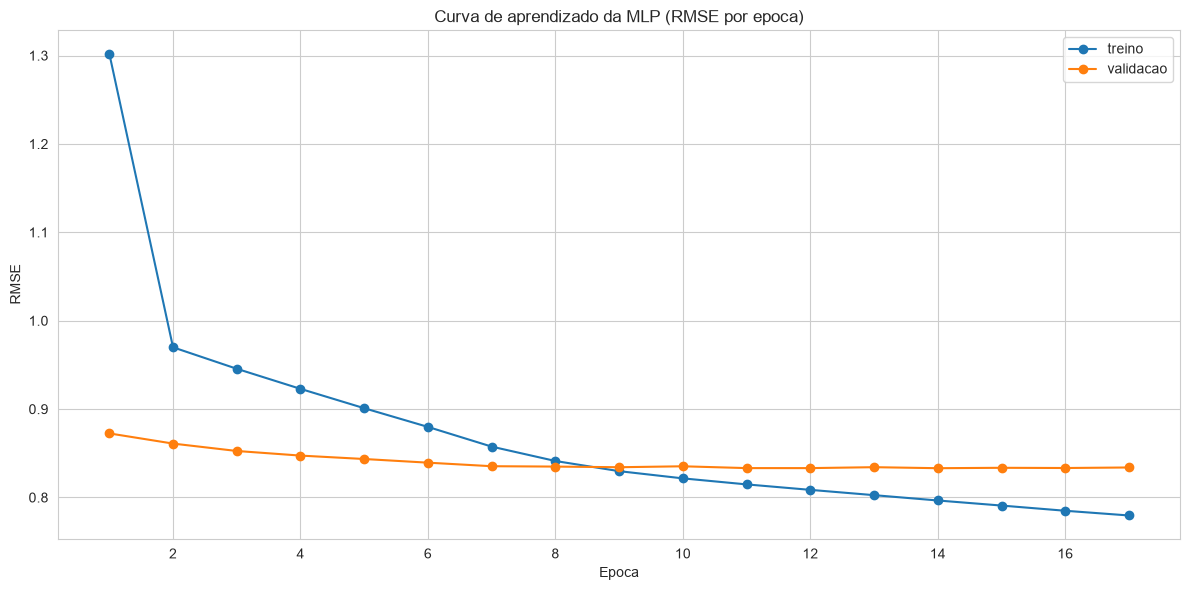

In [19]:
hist = mlp.history
plt.plot(range(1, len(hist["train_rmse"]) + 1), hist["train_rmse"], "o-", label="treino")
plt.plot(range(1, len(hist["val_rmse"]) + 1), hist["val_rmse"], "o-", label="validacao")
plt.title("Curva de aprendizado da MLP (RMSE por epoca)")
plt.xlabel("Epoca")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

## Comparação dos modelos

Tabela consolidada (erro de nota + ranking) e gráfico de RMSE. Quanto **menor** RMSE/MAE/MSE
melhor; quanto **maior** R²/Precision/Recall/NDCG melhor.

=== COMPARACAO DOS MODELOS ===
                rmse     mae     mse      r2  precision_at_10  recall_at_10  ndcg_at_10
GlobalMean    1.0471  0.8289  1.0964 -0.0046           0.1010        0.2092      0.3477
BiasBaseline  0.8700  0.6650  0.7569  0.3064           0.3192        0.3259      0.4193
SVD           0.9907  0.7776  0.9815  0.1006           0.4742        0.4959      0.6534
MLP           0.8537  0.6463  0.7289  0.3321           0.3171        0.3270      0.4182

Melhor RMSE   : MLP (0.8537)
Melhor NDCG@10: SVD (0.6534)


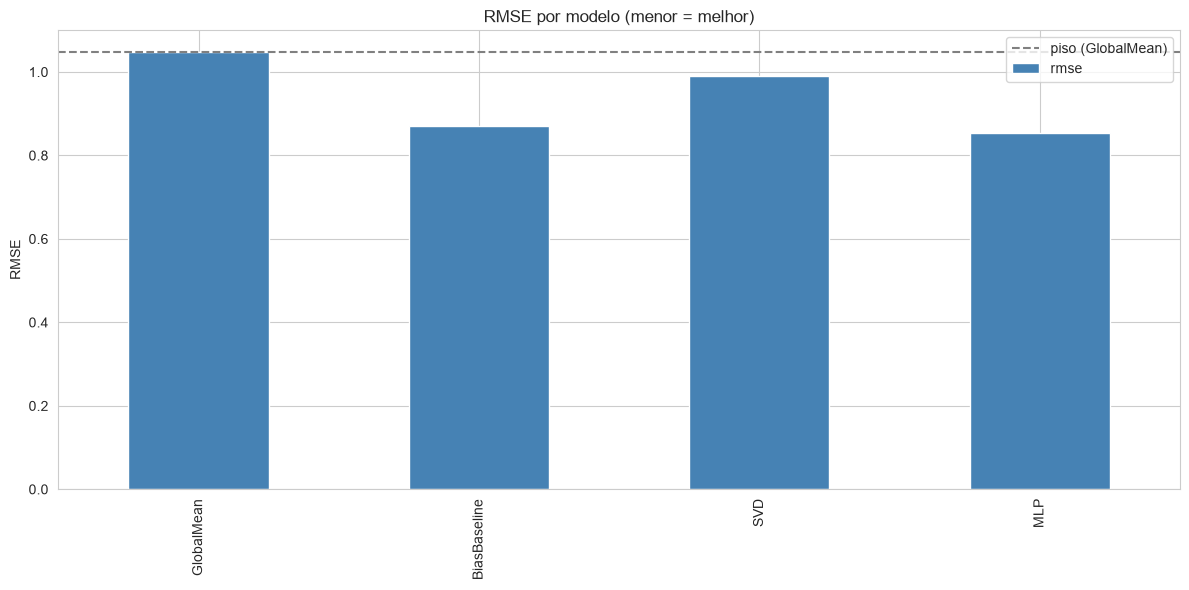

In [20]:
comparison = pd.DataFrame(results).T
comparison = comparison[["rmse", "mae", "mse", "r2",
                         "precision_at_10", "recall_at_10", "ndcg_at_10"]]
print("=== COMPARACAO DOS MODELOS ===")
print(comparison.round(4).to_string())

best_rmse = comparison["rmse"].idxmin()
best_ndcg = comparison["ndcg_at_10"].idxmax()
print(f"\nMelhor RMSE   : {best_rmse} ({comparison.loc[best_rmse, 'rmse']:.4f})")
print(f"Melhor NDCG@10: {best_ndcg} ({comparison.loc[best_ndcg, 'ndcg_at_10']:.4f})")

ax = comparison["rmse"].plot(kind="bar", color="steelblue")
ax.axhline(comparison.loc["GlobalMean", "rmse"], ls="--", color="gray",
           label="piso (GlobalMean)")
ax.set_title("RMSE por modelo (menor = melhor)")
ax.set_ylabel("RMSE")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusões e próximos passos

**O que temos.** Uma base comparável e rastreável: baselines (ingênuo, vieses, SVD) e um
primeiro candidato **MLP com embeddings** em PyTorch, todos sob a mesma interface
`Recommender` e a mesma avaliação (erro de nota + ranking). Tudo logado no MLflow com a
versão do dataset (hash DVC); a MLP fica registrada no Model Registry (`MovieLens_MLP_Reco`).

**Leitura esperada.** O `GlobalMean` é o piso; o `BiasBaseline` costuma ser difícil de
superar em RMSE puro; a MLP tende a ganhar nas métricas de **ranking** ao capturar
interações não lineares usuário×item — exatamente o que importa para a experiência de
recomendação.

**Próximas iterações.**

1. **Tuning** de hiperparâmetros da MLP (dimensão de embedding, profundidade, dropout, lr)
   com validação por *k-fold* temporal e busca rastreada no MLflow.
2. **Arquiteturas mais ricas** (viés explícito + fatores, *features* de conteúdo do *tag
   genome* para mitigar *cold-start*).
3. **Avaliação de ranking em escala completa** (catálogo inteiro, cobertura/diversidade).
4. **Pipeline DVC** (`preprocess → feature_eng → train → evaluate`) e promoção do campeão
   Staging→Production no Model Registry (Etapa 4).